In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [11]:
df = pd.read_csv('https://raw.githubusercontent.com/Dcarlos-02/DATA201__SP26/fb1bba686dc607f0cc1e7f18a30b0a15bae02325/project1/Raw_dataset_laptop_sales.csv')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [12]:
df['Ram'].unique()

array(['8GB', '16GB', '4GB', '2GB', '12GB', '6GB', '32GB', '24GB', '64GB'],
      dtype=object)

In [13]:
df['Ram'] = df['Ram'].str.replace('GB', '')
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [14]:
df.shape

(1303, 12)

In [15]:
df['Memory_type'] = df['Memory'].str.split(' ').str[1]
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_type
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,SSD
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Flash
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,SSD
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,SSD
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,SSD


In [16]:
df['Memory'].unique()

array(['128GB SSD', '128GB Flash Storage', '256GB SSD', '512GB SSD',
       '500GB HDD', '256GB Flash Storage', '1TB HDD',
       '32GB Flash Storage', '128GB SSD +  1TB HDD',
       '256GB SSD +  256GB SSD', '64GB Flash Storage',
       '256GB SSD +  1TB HDD', '256GB SSD +  2TB HDD', '32GB SSD',
       '2TB HDD', '64GB SSD', '1.0TB Hybrid', '512GB SSD +  1TB HDD',
       '1TB SSD', '256GB SSD +  500GB HDD', '128GB SSD +  2TB HDD',
       '512GB SSD +  512GB SSD', '16GB SSD', '16GB Flash Storage',
       '512GB SSD +  256GB SSD', '512GB SSD +  2TB HDD',
       '64GB Flash Storage +  1TB HDD', '180GB SSD', '1TB HDD +  1TB HDD',
       '32GB HDD', '1TB SSD +  1TB HDD', '512GB Flash Storage',
       '128GB HDD', '240GB SSD', '8GB SSD', '508GB Hybrid', '1.0TB HDD',
       '512GB SSD +  1.0TB Hybrid', '256GB SSD +  1.0TB Hybrid'],
      dtype=object)

In [17]:
df['Memory'] = df['Memory'].str.split(' ').str[0]

df['Memory'].replace({'1TB':'1024GB'}, inplace=True)
df['Memory'].replace({'2TB':'2048GB'}, inplace=True)
df['Memory'].replace({'1.0TB':'1024GB'}, inplace=True)
df['Memory'] = df['Memory'].str.replace('GB', '')
df.head()

/tmp/ipykernel_59696/3121745256.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Memory'].replace({'1TB':'1024GB'}, inplace=True)


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_type
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,SSD
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Flash
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256,Intel HD Graphics 620,No OS,1.86kg,30636.0000,SSD
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,SSD
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,SSD


In [18]:
df = df.drop(['Unnamed: 0'], axis=1)
df.head()


,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_type
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,SSD
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,Flash
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256,Intel HD Graphics 620,No OS,1.86kg,30636.0000,SSD
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,SSD
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,SSD


In [19]:
df['Ram'] = df['Ram'].astype(int)
df['Memory'] = df['Memory'].astype(int)

In [20]:
df.isna().sum()

,0
Company,0
TypeName,0
Inches,0
ScreenResolution,0
Cpu,0
Ram,0
Memory,0
Gpu,0
OpSys,0
Weight,0


In [21]:
df.describe()

,Inches,Ram,Memory,Price
count,1303.000000,1303.000000,1303.000000,1303.000000
mean,15.017191,8.382195,447.809670,59870.042910
std,1.426304,5.084665,366.037159,37243.201786
min,10.100000,2.000000,8.000000,9270.720000
25%,14.000000,4.000000,256.000000,31914.720000
50%,15.600000,8.000000,256.000000,52054.560000
75%,15.600000,8.000000,512.000000,79274.246400
max,18.400000,64.000000,2048.000000,324954.720000


In [22]:
df[df['Price']>150000]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Memory_type
17,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.9GHz,16,512,AMD Radeon Pro 560,macOS,1.83kg,152274.2400,SSD
190,Lenovo,2 in 1 Convertible,14.0,Touchscreen 2560x1440,Intel Core i7 7500U 2.7GHz,16,1024,Intel HD Graphics 620,Windows 10,1.42kg,150462.7200,SSD
196,Razer,Gaming,17.3,4K Ultra HD / Touchscreen 3840x2160,Intel Core i7 7820HK 2.9GHz,32,1024,Nvidia GeForce GTX 1080,Windows 10,3.49kg,324954.7200,SSD
204,Dell,Workstation,15.6,4K Ultra HD 3840x2160,Intel Xeon E3-1505M V6 3GHz,16,256,Nvidia Quadro M1200,Windows 10,2.8kg,162770.4000,SSD
238,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,32,512,Nvidia GeForce GTX 1080,Windows 10,4.7kg,207259.2000,SSD
247,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7820HK 2.9GHz,16,256,Nvidia GeForce GTX 1080,Windows 10,3.6kg,159786.7200,SSD
297,Dell,Workstation,17.3,Full HD 1920x1080,Intel Core i7 7820HQ 2.9GHz,16,256,Nvidia Quadro M1200,Windows 10,3.42kg,153705.3408,SSD
517,Asus,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,24,512,Nvidia GeForce GTX1080,Windows 10,2.24kg,158135.0400,SSD
530,Dell,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,128,Nvidia GeForce GTX 1070,Windows 10,4.42kg,160520.3856,SSD
563,Lenovo,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,256,Nvidia Quadro M620M,Windows 10,3.4kg,159786.7200,SSD


In [34]:
df['Price'] = np.where(df['Price']>150000, 150000, df['Price'])


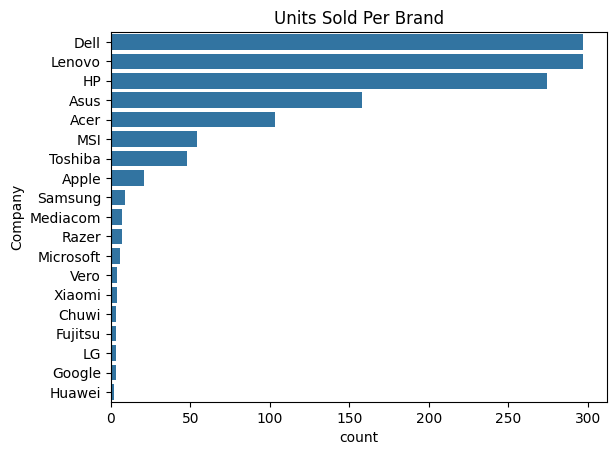

In [35]:
#grouping data by company to plot total unit sold
qty_sold_per_brand = df.groupby('Company')['Company'].value_counts().sort_values(ascending=False).reset_index()

sns.barplot(x='count', y='Company', data=qty_sold_per_brand)
plt.title('Units Sold Per Brand')
plt.show()

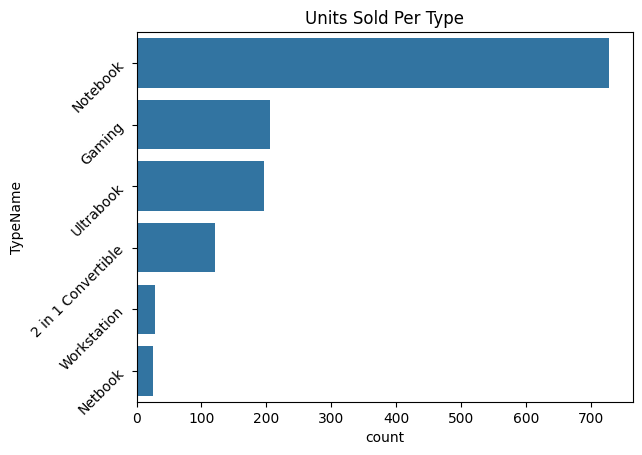

In [39]:
#grouping data by model to plot total unit sold
units_sold_per_type = df.groupby('TypeName')['TypeName'].value_counts().sort_values(ascending=False).reset_index()
sns.barplot(x='count', y='TypeName', data=units_sold_per_type)
plt.title('Units Sold Per Type')
plt.yticks(rotation=45)
plt.show()

In [24]:
df['TypeName'].unique()

array(['Ultrabook', 'Notebook', 'Netbook', 'Gaming', '2 in 1 Convertible',
       'Workstation'], dtype=object)

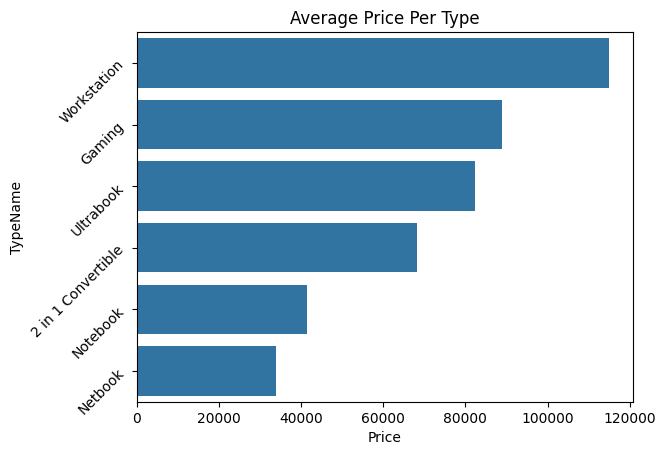

In [36]:
#grouping data by model
avg_price_per_type = df.groupby('TypeName')['Price'].mean().sort_values(ascending=False).reset_index()
#plotting average price by model
sns.barplot(x='Price', y='TypeName', data=avg_price_per_type)
plt.title('Average Price Per Type')
plt.yticks(rotation=45)
plt.show()

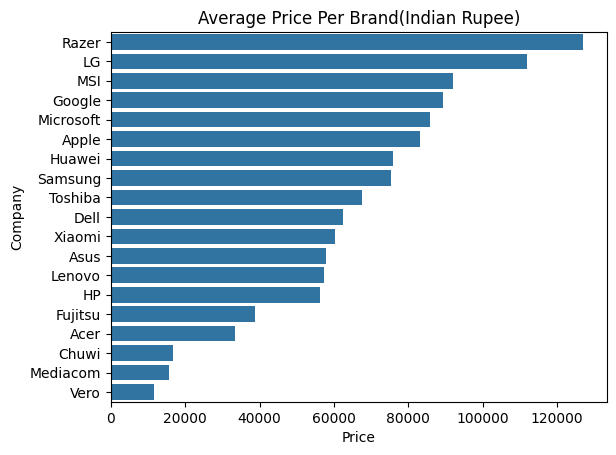

In [37]:
#grouping data by company
avg_price = df.groupby('Company')['Price'].mean().sort_values(ascending=False).reset_index()
#plotting average price by brand
sns.barplot(x='Price', y='Company', data=avg_price)
plt.title('Average Price Per Brand(Indian Rupee)')
plt.show()

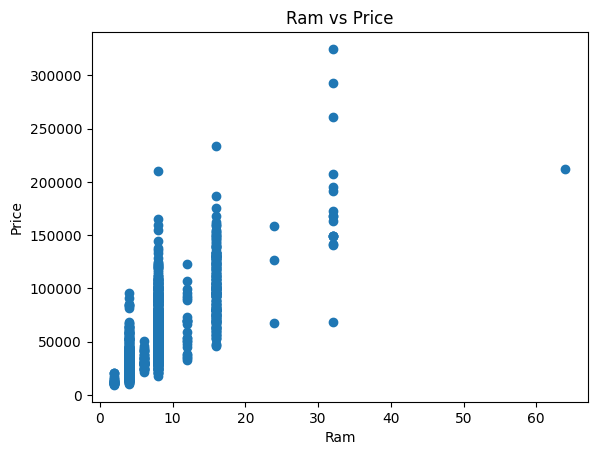

In [26]:
plt.scatter(df['Ram'], df['Price'])
plt.title('Ram vs Price')
plt.xlabel('Ram')
plt.ylabel('Price')
plt.show()

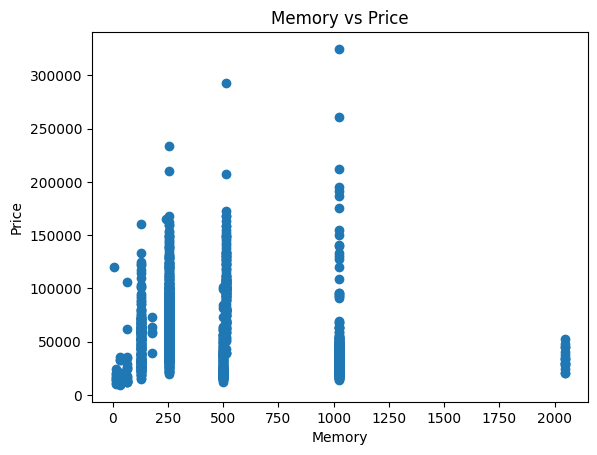

In [27]:
plt.scatter(df['Memory'], df['Price'])
plt.title('Memory vs Price')
plt.xlabel('Memory')
plt.ylabel('Price')
plt.show()

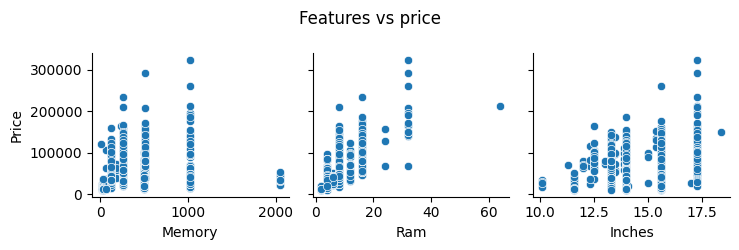

In [28]:
#associating price with physical features of laptops
sns.pairplot(df, x_vars=['Memory', 'Ram','Inches'], y_vars=['Price'])
plt.suptitle("Features vs price")
plt.tight_layout()
plt.show()

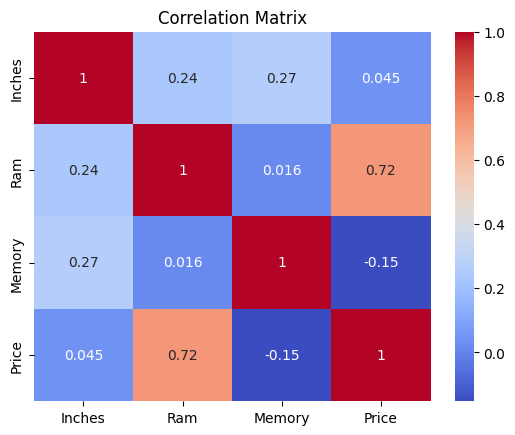

In [46]:
#Heatmap of correlation between numeric variables

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

Text(0, 0.5, 'Frequency')

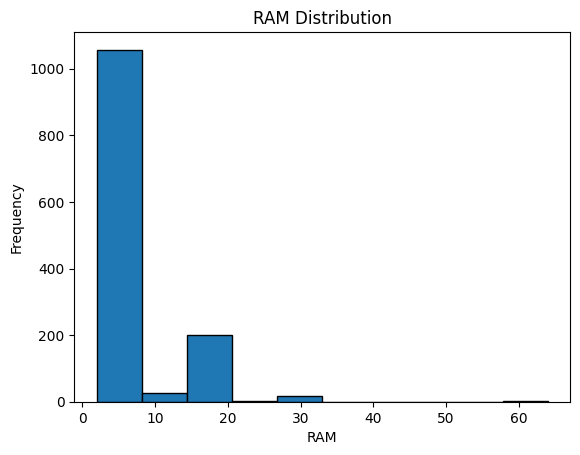

In [42]:
#plotting the distribution of RAM
plt.hist(df['Ram'], bins=10, edgecolor='black')
plt.title('RAM Distribution')
plt.xlabel('RAM')
plt.ylabel('Frequency')

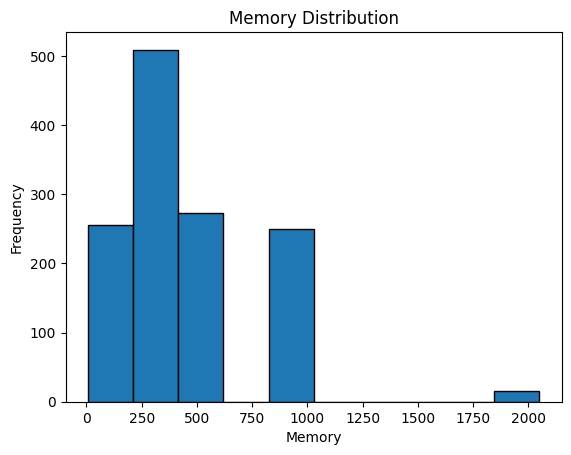

In [44]:
#plotting the distribution of storage
plt.hist(df['Memory'], bins=10, edgecolor='black')
plt.title('Memory Distribution')
plt.xlabel('Memory')
plt.ylabel('Frequency')
plt.show()

In [55]:


#10 percent sample
sample_df = df.sample(frac=0.1, random_state=42)

#nbr of iterations
n_bootstrap = 10000


# Bootstrapping for Median
boot_medians = []
for i in range(n_bootstrap):
  resample = np.random.choice(sample_df['Price'], size=len(sample_df['Price']), replace=True)
  boot_medians.append(np.median(resample))

#computing the confidence interval
lower = np.percentile(boot_medians, 2.5)
upper = np.percentile(boot_medians, 97.5)

print(f'Sample Median Price: {median_val:.2f}')
print(f'95% Confidence Interval for the Median: [{ci_low:.2f}, {ci_high:.2f}]')

Sample Median Price: 50189.76
95% Confidence Interval for the Median: [43023.60, 57096.45]
